In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
import pandas as pd

df = pd.read_csv("superstore.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'superstore.csv'

In [3]:
import pandas as pd

df = pd.read_csv("superstore.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'superstore.csv'

In [4]:
import os
os.getcwd()

'C:\\Users\\sreev'

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\sreev\OneDrive\Documents\Projects\Retail_Sales_Analysis.ipynb\superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

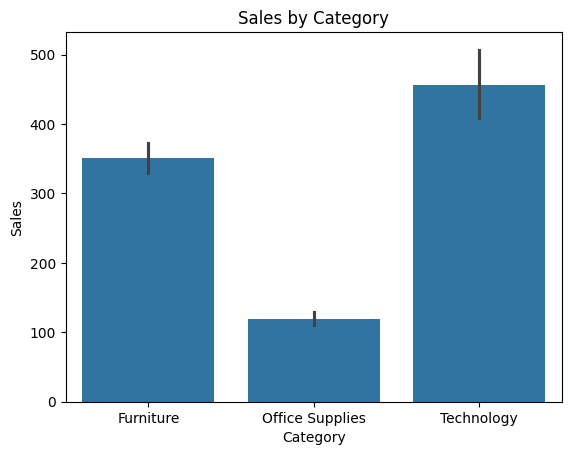

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Category", y="Sales", data=df)
plt.title("Sales by Category")
plt.show()

In [10]:
df["Sales"].sum()

np.float64(2261536.7827)

In [11]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [12]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

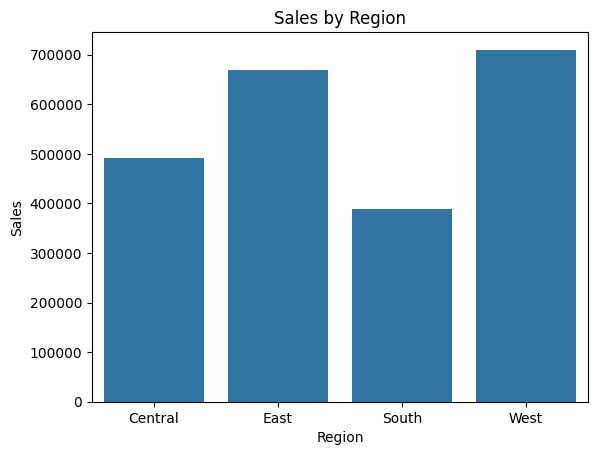

In [13]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

sns.barplot(x="Region", y="Sales", data=region_sales)

plt.title("Sales by Region")
plt.show()

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [16]:
df["Month"] = df["Order Date"].dt.month

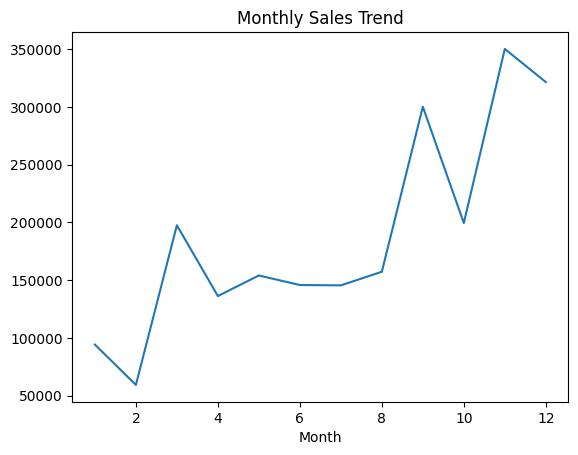

In [17]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot()

import matplotlib.pyplot as plt
plt.title("Monthly Sales Trend")
plt.show()

In [ ]:
Insight:

Sales show seasonal variation across months.
Certain months generate higher revenue, indicating possible seasonal demand.

In [18]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

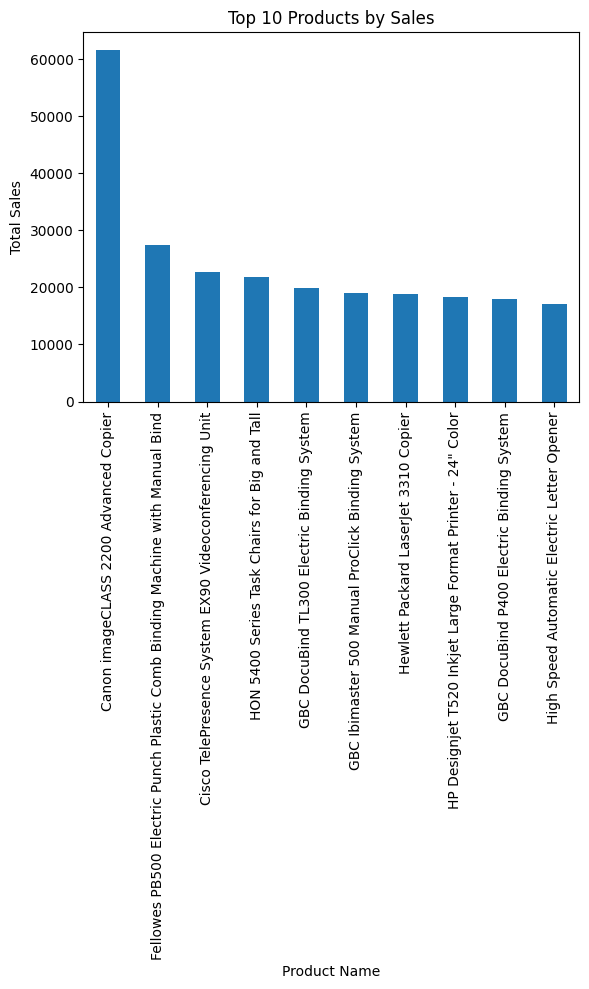

In [19]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
Insight:

The top 10 products contribute a large portion of total revenue.
High-performing products like Canon and Cisco equipment dominate sales.
Businesses can focus marketing on these high-performing products.

In [20]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

KeyError: 'Column not found: Profit'

In [21]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month'],
      dtype='str')

In [22]:
df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

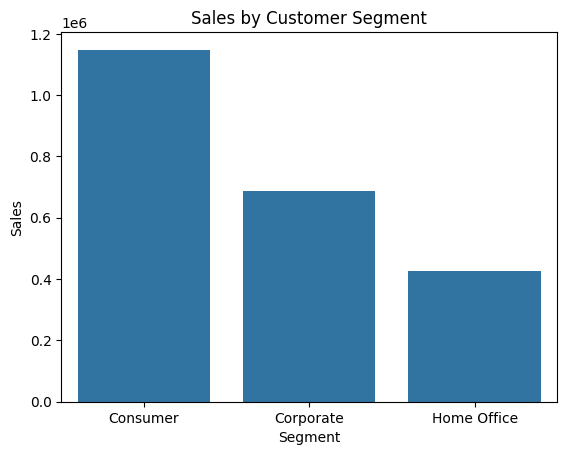

In [23]:
segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()

sns.barplot(x="Segment", y="Sales", data=segment_sales)

plt.title("Sales by Customer Segment")
plt.show()

In [ ]:
Insights:

1. Technology category generates the highest sales revenue.
2. The West region contributes the largest share of total sales.
3. Consumer segment drives the majority of purchases.

In [25]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

top_cities

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64

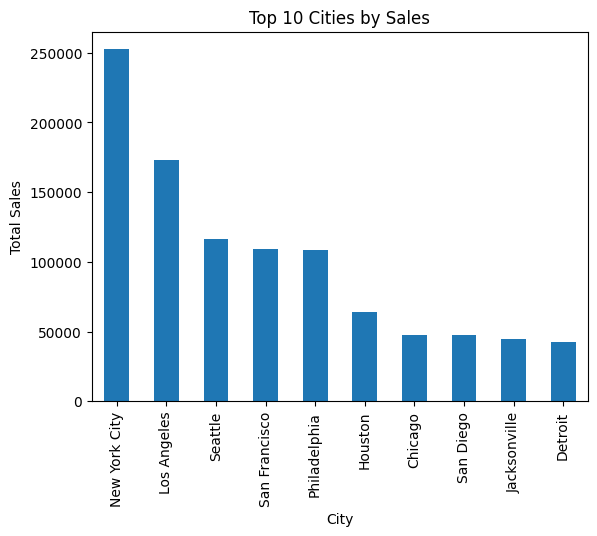

In [26]:
top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()

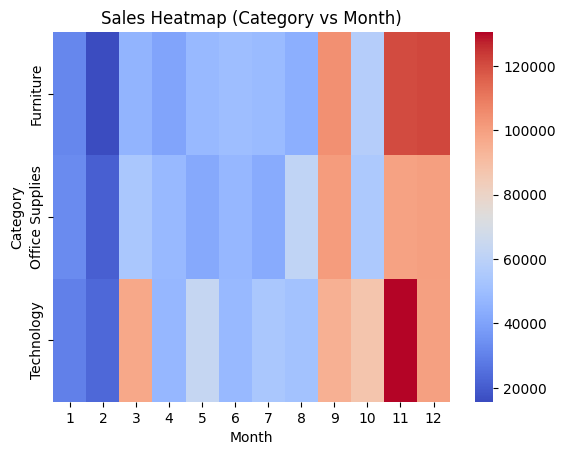

In [27]:
import seaborn as sns

heatmap_data = df.pivot_table(values="Sales", index="Category", columns="Month", aggfunc="sum")

sns.heatmap(heatmap_data, cmap="coolwarm")

plt.title("Sales Heatmap (Category vs Month)")
plt.show()

In [ ]:
Insights:

• Certain products contribute significantly to overall revenue.
• Major cities generate a higher share of sales.
• Sales show seasonal patterns across months.
• Technology products perform consistently across most months.